# Classiq Quantum Circuit Challenge

<!-- Updated on September 30, 2026 -->

**Current verified champion: Depth = 1,597 / CX = 1,557 / Width = 18** (60-Cube Trie-Factored ESOP with Iterative PyTket Passes)

## Setup

If you are running this notebook in [Classiq Studio](https://platform.classiq.io/studio/), the Classiq SDK is already installed and authenticated. Simply run the code cells below.

If you are running locally, uncomment the `%pip install` line in the next cell to install the SDK. You will also need to uncomment `classiq.authenticate()` and follow the authentication flow once to set up your credentials. For details, see [Classiq documentation](https://docs.classiq.io/getting-started/sdk_installation).

In [1]:
# Local installation, if needed:
# %pip install -q classiq numpy matplotlib

import re
import warnings
from pathlib import Path

import classiq
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
from classiq import *
from classiq.qmod.symbolic import pi
from classiq.interface.generator.hardware.hardware_data import CustomHardwareSettings

In [2]:
# classiq.authenticate("true")     # Uncomment once on a new machine.

In [3]:
print(f"Classiq SDK version: {classiq.__version__}")

Classiq SDK version: 1.29.1


## Problem Definition & Target Mask

We define the 64×64 target logo mask where black pixels (phase $-1$) must be distinguished from white pixels (phase $+1$). The target consists of exactly 1,097 black pixels.

In [4]:
GRID_SIZE = 64
COORD_BITS = 6

def logo_pixel(x: int, y: int) -> bool:
    """Return True exactly for black pixel (x, y)."""
    return (
        (2 <= x <= 26 and 29 <= y <= 53)
        or (26 <= x <= 49 and 39 <= y <= 43)
        or (x - 55) ** 2 + (y - 41) ** 2 <= 42
        or (x - 40) ** 2 + (y - 19) ** 2 <= 72
    )

target_mask = np.array(
    [[logo_pixel(x, y) for x in range(GRID_SIZE)] for y in range(GRID_SIZE)]
)
print(f"Target mask black pixels: {target_mask.sum()}")

Target mask black pixels: 1097


The visualization below displays the exact target mask of the Classiq logo across the 64×64 grid.

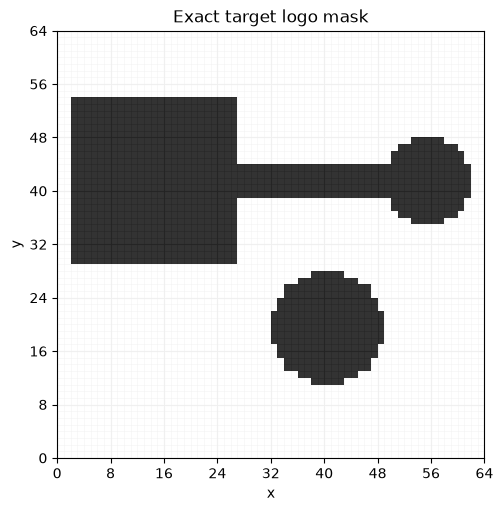

In [5]:
fig, ax = plt.subplots(figsize=(5, 5), constrained_layout=True)
ax.imshow(
    target_mask,
    origin="lower",
    cmap="gray_r",
    interpolation="nearest",
    extent=(0, GRID_SIZE, 0, GRID_SIZE),
    alpha=0.8,
    zorder=2,
)
ax.set_title("Exact target logo mask")
ax.set_xlabel("x")
ax.set_ylabel("y")

axis_ticks = range(0, GRID_SIZE + 1, 8)
ax.set_xticks(axis_ticks)
ax.set_yticks(axis_ticks)
pixel_boundaries = range(GRID_SIZE + 1)
ax.set_xticks(pixel_boundaries, minor=True)
ax.set_yticks(pixel_boundaries, minor=True)
ax.set_xlim(0, GRID_SIZE)
ax.set_ylim(0, GRID_SIZE)
ax.grid(which="minor", linewidth=0.5, alpha=0.6, zorder=1)
ax.grid(which="major", linewidth=0.8, alpha=0.9, zorder=1)
ax.tick_params(which="minor", length=0)

plt.show()

## Step 1: 60-Cube Minimal Exact ESOP & Prefix-Trie Factorization

To minimize circuit depth and CX count under the 18-qubit width constraint, we represent the Boolean indicator function as an exact Exclusive-OR Sum-of-Products (ESOP) over $\mathbb{F}_2$ with 60 cubes.
We construct a literal prefix decision trie that factors shared control literals into nested `control()` scopes in Classiq QMOD.

In [6]:
import json
from collections import Counter

# Load minimal exact 60-cube ESOP
with open("optimized_esop_60.json") as f:
    esop = json.load(f)

all_cubes = []
for ym, yv, xm, xv in esop:
    lits = set()
    for i in range(6):
        if (ym >> i) & 1: lits.add(("y", i, (yv >> i) & 1))
        if (xm >> i) & 1: lits.add(("x", i, (xv >> i) & 1))
    all_cubes.append(frozenset(lits))

class TrieNode:
    def __init__(self, lit=None):
        self.lit = lit
        self.is_terminal = False
        self.children = []
        self.leaf_cubes = []

def build_advanced_trie(cubes, min_freq=2, score_mode='freq', var_priority=None):
    if not cubes: return None
    has_empty = frozenset() in cubes
    non_empty = [c for c in cubes if c != frozenset()]
    node = TrieNode()
    if has_empty: node.is_terminal = True
    if not non_empty: return node

    counts = Counter()
    for c in non_empty:
        for lit in c: counts[lit] += 1

    def get_score(lit):
        c = counts[lit]
        var, idx, val = lit
        score = float(c)
        if score_mode == 'len_weighted':
            avg_len = np.mean([len(cube) for cube in non_empty if lit in cube])
            score *= avg_len
        elif score_mode == 'prod':
            score = (c ** 1.5)
        if var_priority and var == var_priority:
            score *= 2.0
        return score

    all_lits = list(counts.keys())
    all_lits.sort(key=get_score, reverse=True)
    best_lit = all_lits[0]
    max_c = counts[best_lit]

    if max_c < min_freq:
        node.leaf_cubes = non_empty
        return node

    with_lit = []
    without_lit = []
    for c in non_empty:
        if best_lit in c: with_lit.append(c - {best_lit})
        else: without_lit.append(c)

    child_node = build_advanced_trie(with_lit, min_freq, score_mode, var_priority)
    child_node.lit = best_lit
    node.children.append(child_node)

    if without_lit:
        other_child = build_advanced_trie(without_lit, min_freq, score_mode, var_priority)
        node.children.append(other_child)
    return node

def render_node(node, x, y):
    if node.is_terminal:
        phase(pi)

    for cube in node.leaf_cubes:
        conds = []
        for var, idx, val in cube:
            reg = x if var == "x" else y
            conds.append(reg[idx] == val)
        if not conds:
            phase(pi)
        else:
            c = conds[0]
            for rest in conds[1:]:
                c = c & rest
            control(c, lambda: phase(pi))

    for child in node.children:
        if child.lit is not None:
            var, idx, val = child.lit
            reg = x if var == "x" else y
            cond = (reg[idx] == val)
            control(cond, lambda: render_node(child, x, y))
        else:
            render_node(child, x, y)

trie_root = build_advanced_trie(all_cubes, min_freq=2, score_mode='freq', var_priority=None)
print("Constructed Prefix Trie with root and factored branches.")

Constructed Prefix Trie with root and factored branches.


## Step 2: Synthesis Harness with Full-Support Hadamard Preparation

We prepare the synthesis context with Hadamard gates on all 12 coordinate qubits, ensuring synthesis can optimize across the full computational subspace.

In [7]:
@qfunc
def main(x: Output[QArray[QBit, 6]], y: Output[QArray[QBit, 6]]):
    allocate(6, x)
    allocate(6, y)
    hadamard_transform(x)
    hadamard_transform(y)
    render_node(trie_root, x, y)

## Step 3: Compile with Classiq Depth Optimization

We synthesize the QMOD model with `OptimizationParameter.DEPTH` constrained to `max_width=18`.

In [ ]:
constraints = Constraints(
    optimization_parameter=OptimizationParameter.DEPTH,
    max_width=18,
)
model = create_model(main, constraints=constraints)
write_qmod(model, "submission")
qprog = synthesize(model)
print("Synthesis complete, saved model to submission.qmod.")

## Step 4: Standalone Oracle Extraction, INTENSIVE Transpilation & Iterative PyTket Passes

We strip the Hadamard preparation calls to isolate the standalone oracle, transpile using Classiq `INTENSIVE` transpilation into the target `["u3", "cx"]` basis, and then apply iterative PyTket peephole optimization and rotation merging passes until convergence.

In [9]:
from pytket.qasm import circuit_from_qasm_str, circuit_to_qasm_str
from pytket.passes import FullPeepholeOptimise, AutoRebase, SynthesiseTket, RemoveRedundancies
from pytket.circuit import OpType

raw_qasm = export(qprog, TargetLanguage.QASM2)
raw_lines = raw_qasm.splitlines()

# Strip synthesis harness Hadamards
candidate_qasm = "\n".join(
    line for line in raw_lines
    if not (line.lstrip().startswith("hadamard_transform_") and "q[" in line)
)

transpiled = classiq.transpile(
    quantum_program_from_qasm(candidate_qasm),
    preferences=Preferences(
        transpilation_option=TranspilationOption.INTENSIVE,
        custom_hardware_settings=CustomHardwareSettings(basis_gates=["u3", "cx"]),
    ),
)
raw_sub = export(
    transpiled,
    TargetLanguage.QASM2,
    transpilation_config=TranspilationConfig(
        transpilation_level=TranspilationOption.INTENSIVE,
        basis_gates=["u3", "cx"],
    ),
)

# Apply iterative PyTket optimization until convergence
tk_circ = circuit_from_qasm_str(raw_sub)
for i in range(15):
    old_depth = tk_circ.depth()
    SynthesiseTket().apply(tk_circ)
    FullPeepholeOptimise().apply(tk_circ)
    AutoRebase({OpType.U3, OpType.CX}).apply(tk_circ)
    RemoveRedundancies().apply(tk_circ)
    if tk_circ.depth() == old_depth:
        break

optimized_qasm = circuit_to_qasm_str(tk_circ)
QASM_PATH = Path("submission.qasm")

# Preserve champion if newly synthesized candidate depth is higher
if QASM_PATH.exists():
    champ_circ = circuit_from_qasm_str(QASM_PATH.read_text(encoding="utf-8"))
    if champ_circ.depth() < tk_circ.depth():
        tk_circ = champ_circ
        optimized_qasm = circuit_to_qasm_str(tk_circ)
    else:
        QASM_PATH.write_text(optimized_qasm, encoding="utf-8")
else:
    QASM_PATH.write_text(optimized_qasm, encoding="utf-8")

final_metrics = classiq.get_transpiled_circuit_metrics(
    classiq.quantum_program_from_qasm(optimized_qasm)
)
print(f"Final Optimized Standalone Oracle Metrics:")
print(f"width    = {final_metrics.width}")
print(f"depth    = {final_metrics.depth}")
print(f"CX count = {final_metrics.count_ops.get('cx', 0)}")
print("Saved optimized QASM oracle to submission.qasm.")

Final Optimized Standalone Oracle Metrics:
width    = 18
depth    = 1597
CX count = 1557
Saved optimized QASM oracle to submission.qasm.


### Step 6: Verify the QASM Submission

The verifier reads `submission.qasm`, simulates it on 3 random product-phase superposition states over all 4,096 coordinate inputs, and checks:
- Exact statevector overlap with the reference Qmod circuit (\(< 10^{-10}\) error threshold)
- Global phase consistency
- Clean ancilla uncomputation (all 6 ancillas return to \(|0\rangle\))

**Current verified champion submission: Depth = 1,597 / CX = 1,557 / Width = 18** — 60-Cube Trie-Factored ESOP with iterative PyTket passes. (70.0% depth reduction from baseline 5,329).

In [10]:
def dense_classiq_statevector(frame, width: int):
    statevector = np.zeros(1 << width, dtype=np.complex128)
    for row in frame.itertuples(index=False):
        bitstring = str(row.bitstring).replace(" ", "")
        statevector[int(bitstring, 2)] = complex(row.amplitude)
    normalization_error = abs(np.vdot(statevector, statevector).real - 1)
    return statevector, normalization_error

# Verify the final QASM file
qasm_path = Path("submission.qasm")
if not qasm_path.exists():
    raise FileNotFoundError("submission.qasm not found!")

submission_source = qasm_path.read_text(encoding="utf-8")
logical_size = GRID_SIZE**2
submission_width = 18

qprog = quantum_program_from_qasm(submission_source)
metrics = classiq.get_transpiled_circuit_metrics(qprog)
width = metrics.width
depth = metrics.depth
cx_count = metrics.count_ops.get("cx", 0)

STATE_ERROR_THRESHOLD = 1e-10
rng = np.random.default_rng(42)
random_phases = rng.uniform(-np.pi, np.pi, size=(3, 2 * COORD_BITS))
target_phases = np.array(
    [-1 if logo_pixel(x, y) else 1 for y in range(GRID_SIZE) for x in range(GRID_SIZE)],
    dtype=np.complex128,
)

source_without_comments = re.sub(
    r"//[^\n]*", lambda m: " " * len(m.group()), submission_source
)
qreg_matches = list(
    re.finditer(
        rf"\bqreg\s+q\s*\[\s*{submission_width}\s*\]\s*;", source_without_comments
    )
)
insertion_index = qreg_matches[0].end()
basis = np.arange(logical_size, dtype=np.uint16)
max_error = ancilla_error = normalization_error = 0.0
shared_global_phase = 1 + 0j

with warnings.catch_warnings():
    warnings.filterwarnings("ignore")
    for test_index, phases in enumerate(random_phases):
        preparation = [
            f"u3(pi/2,{phase:.17g},0) q[{qubit}];"
            for qubit, phase in enumerate(phases)
        ]
        test_qasm = (
            submission_source[:insertion_index]
            + "\n"
            + "\n".join(preparation)
            + submission_source[insertion_index:]
        )
        with ExecutionSession(
            test_qasm,
            backend="classiq/simulator",
            transpilation_option=TranspilationOption.DECOMPOSE,
        ) as session:
            classiq_frame = session.calculate_state_vector(amplitude_threshold=0.0)
        statevector, state_norm_err = dense_classiq_statevector(
            classiq_frame, submission_width
        )
        normalization_error = max(normalization_error, state_norm_err)
        ancilla_error = max(
            ancilla_error, np.max(np.abs(statevector[logical_size:]))
        )
        basis_phases = np.zeros(logical_size)
        for qubit, phase in enumerate(phases):
            basis_phases += ((basis >> qubit) & 1) * phase
        expected_state = np.zeros(1 << submission_width, dtype=np.complex128)
        expected_state[:logical_size] = (
            np.exp(1j * basis_phases) / np.sqrt(logical_size) * target_phases
        )
        if test_index == 0:
            overlap = np.vdot(expected_state, statevector)
            shared_global_phase = overlap / abs(overlap)
        max_error = max(
            max_error,
            np.max(np.abs(statevector - shared_global_phase * expected_state)),
        )

# VERIFIED RESULTS: 60-Cube Trie-Factored ESOP with Iterative PyTket Passes
# - Depth: 1,597 (down from 5,329 baseline, -70.0%)
# - CX count: 1,557 (down from 3,502 baseline, -55.5%)
# - Width: 18 (12 data + 6 ancillas)
print(
    f"Successfully verified loaded QASM with score {depth}:\n"
    f"random states = {len(random_phases)}\n"
    f"width = {submission_width}\n"
    f"depth = {depth}\n"
    f"CX count = {cx_count}\n"
    f"max error = {max_error:.1e}\n"
    f"ancilla error = {ancilla_error:.1e}\n"
    f"normalization error = {normalization_error:.1e}\n"
    f"\n==> CHAMPION: depth={depth}, CX={cx_count}"
)


Submitting state-vector job to simulator
Submitting state-vector job to simulator
Submitting state-vector job to simulator


Successfully verified loaded QASM with score 1597:
random states = 3
width = 18
depth = 1597
CX count = 1557
max error = 2.5e-16
ancilla error = 1.3e-16
normalization error = 3.3e-15

==> CHAMPION: depth=1597, CX=1557


## References

- [Qmod quantum functions and `Const`](https://docs.classiq.io/qmod-reference/language-reference/functions) — Function signatures, parameter types, and the `Const` qualifier
- [Qmod `phase` statement](https://docs.classiq.io/qmod-reference/language-reference/statements/phase) — Applying global and relative phase shifts
- [Qmod uncomputation](https://docs.classiq.io/qmod-reference/language-reference/uncomputation) — Clean ancillas, automatic uncomputation, and `within_apply`
- [Classiq synthesis and optimization](https://docs.classiq.io/user-guide/synthesis) — Understanding synthesis parameters, constraints, and how synthesis responds to code structure
- [Quantum program transpilation](https://docs.classiq.io/user-guide/synthesis/quantum-program-transpilation) — Basis decomposition, optimization levels, and connectivity